YOU NEED TO CHANGE THE REFINEMENT PATCH TO ACCOMMODATE THE ORDER OF INTERPOLATION FOR COARSER GRIDS!!!

In [1]:
import os.path
from scipy import *
import numpy as np
from numpy import *
from numpy import linalg as LA
from scipy import linalg as LA2
import sympy as sympy
import sys as sys
import csv
import time
import matplotlib.pyplot as plt
import itertools as it
from IPython.core.display import HTML
from fractions import Fraction


sys.path.append('/Users/sashacurcic/SashasDirectory/ANAG/FV_MG/')
from Modules import BasicTools as BT
from Modules import WaveTools as WT
from Modules import PlotTools as PT
from Modules import FFTTools as FFTT
from Modules import OperatorTools as OT
from Modules import GridTransferTools as GTT
from Modules import TestTools as TT
from Modules import SolverTools as ST
from Modules import WaveformTools as WFT

display(HTML("<style>pre { white-space: pre !important; }</style>"))
np.set_printoptions( linewidth = 10000, threshold = 100000)

In [2]:
nh_min = 16
refRatio = 2
CFL = np.sqrt(0.5)
x_0 = 0.
x_1 = 0.5
Hans = False

All = True

deriv = 'UD'
RK = 1

L = 1
locs = [x_1]
epsilons = [1, 0.25] # [1, 1] # 
mus = [1, 1] # [1]#, 1] # 

func = WFT.Gauss#Deriv
derivative = False

dataPts = 5
plot = False

AMR = True
Uniform = False

Maxwell = True
Advect = False

Two = True

In [3]:
title = 'RK' + str(RK) + ' Error Decay for Gaussian'

In [4]:
omega0 = BT.Grid(nh_min)
physics = BT.PhysProps(omega0, epsilons, mus, locs, L)

In [5]:
if (func == WFT.Polynomial):
    polyorder = 1
    x_0 = 0
    coefs = 16 * np.ones(polyorder+1, float)
    coefs[0] = 0
    args = [x_0, coefs]
else:
    sigma, mu = WFT.GaussParams(x_0, x_1)
    args = [sigma, mu]
    funcString = 'Gauss'
    if (derivative):
        funcString = funcString + 'Deriv'
    funcString = funcString + '/'

In [6]:
def WaveEqConvergenceTest(omega0, physics0, CFL, RK, order, diff, func, args, dataPts, AMR, sameTime = False, numRefCel = 0, plot = True, derivative = False):
    override = True
    
    nh_min = omega0.nh_min
    epsilons = physics0.epsilons_r
    mus = physics0.mus_r
    locs = physics0.locs
    L = physics0.L
    cMat0 = physics0.cMat
    
    nt = 1
    if (sameTime):
        t0, nt = ST.CalcTime(omega0, CFL, cMat0, nt = nt)
    errorE = np.zeros(dataPts, float)
    errorB = np.zeros(dataPts, float)
    errorTot = np.zeros(dataPts, float)
    nhPower = np.arange(dataPts)
    nhVec = nh_min * (2 ** nhPower)
    refRatio = 2
    if (numRefCel == 0):
        halfO = np.ceil(order / 2)
    else:
        halfO = numRefCel
    print(nhVec)

    labels = ['Initial Wave', 'Exact Propagated Wave', 'RK-Propagated Wave']
    for i in range(dataPts):

        print('iter:', i)
        nh = 2 ** (i + 4)
        print('nh:', nh)
        omega = BT.Grid(nh)
        if (AMR):
            finepart = list(int(nh / 2) + np.arange(-int((halfO * nh) / nh_min), int((halfO * nh) / nh_min)))
            omega.AddPatch(refRatio, finepart)
            print(finepart)

        xCell = omega.xCell
        physics = BT.PhysProps(omega, epsilons, mus, locs, L)
        degFreed = omega.degFreed
        waves = WT.MakeWaves(omega)
        nullspace = OT.FindNullspace(omega, waves)
#         waves = waves @ nullspace
        wavesMat = OT.Block(waves, var = 2)
        nullspaceBlock = OT.Block(nullspace, var = 2)
        
        c = physics.cVec
        cMat = physics.cMat
        c1 = c[0]
        c2 = c[-1]

        if (sameTime):
            t, nt = ST.CalcTime(omega, CFL, cMat, t = t0)
            t = t0
        else:
            t, nt = ST.CalcTime(omega, CFL, cMat, nt = nt, override = override)
        

        waveInit = WFT.InitCond(omega, physics, func, args, deriv = derivative)
        FCoefs = FFTT.FourierCoefs(waves @ nullspace, waveInit)
        print('t:', t, Fraction(t).limit_denominator(10**6))

        wavePropEx = WFT.WaveEq(omega, physics, func, args, t, deriv = derivative)

        # Find propagated coeficients on coarse and fine grid.
        FCoefsProp = FFTT.FourierCoefs(waves @ nullspace, wavePropEx)

        solverCoefs = ST.RungeKutta(omega, physics, waveInit, CFL, nt, RK, order, deriv, ST.WaveEqRHS, override)
        wavePropSolv = wavesMat @ nullspaceBlock @ solverCoefs
        
        errorVec = wavePropEx - wavePropSolv
        errorTot[i] = TT.VectorNorm(abs(errorVec), 'max')
        errorE[i] = TT.VectorNorm(abs(errorVec[:nh])[order:-order], 'max')
        errorB[i] = TT.VectorNorm(abs(errorVec[nh:]), 'max')

        allCoefs = PT.Load(FCoefs, FCoefsProp, solverCoefs)
        allCoefs = nullspaceBlock @ allCoefs
        
        np.set_printoptions(precision=24, suppress=True)
        if ((locs != []) and (c1 == c2)):
            physics2 = BT.PhysProps(omega, [epsilons[0]], [mus[0]], [], L)
            solverCoefsAdvect = ST.RungeKutta(omega, physics2, waveInit, CFL, nt, RK, order, deriv, ST.AdvectRHS, override)
            wavePropExAdvectE = WFT.Advect(omega, physics2, func, args, t)
            wavePropExAdvectB = wavePropExAdvectE / c1
            wavePropExAdvect = np.append(wavePropExAdvectE, wavePropExAdvectB)
            wavePropSolvAdvect = wavesMat @ nullspaceBlock @ solverCoefsAdvect
            errorVecAdvect = wavePropExAdvect - wavePropSolvAdvect
            errorEAdvect = TT.VectorNorm(abs(errorVecAdvect[:nh])[order:-order], 'max')
            print('Max norm errors vs difference:', errorE[i], errorEAdvect, errorE[i] - errorEAdvect)
            if not all(wavePropEx == wavePropExAdvect):
                print('Exact Solution:')
                print(wavePropEx)
                print(wavePropExAdvect)
                print(wavePropEx - wavePropExAdvect)
                print('')
#                 sys.exit('Problem with Exact Solution!')
            if not all(errorVec[order:-order] == errorVecAdvect[order:-order]):
                print('Error:')
                print(errorVec)
                print(errorVecAdvect)
                print(errorVec - errorVecAdvect)
                print('')
#                 sys.exit('Problem with Error!')
            if not all(wavePropSolv[order:-order] == wavePropSolvAdvect[order:-order]):
                print('Solver Solution:')
                print(wavePropSolv)
                print(wavePropSolvAdvect)
                print(wavePropSolv - wavePropSolvAdvect)
                print('')
#                 sys.exit('Problem with Solver Solution!')
            if not all(solverCoefs[order:-order] == solverCoefsAdvect[order:-order]):
                print('Fourier Coefficients:')
                print(solverCoefs)
                print(solverCoefsAdvect)
                print(solverCoefs - solverCoefsAdvect)
                print('')
#                 sys.exit('Problem with Solver Solution Fourier Coefficients!')
        

        
        
        
        errorCoefs = PT.Load(FFTT.FourierCoefs(waves @ nullspace, errorVec))
        if (order == 1):
            orderString = str(order) + 'st'
        else:
            if (order == 2):
                orderString = str(order) + 'nd'
            else:
                if (order == 3):
                    orderString = str(order) + 'rd'
                else:
                    orderString = str(order) + 'th'
        
#         if (AMR and (RK == 4) and ((diff == 'U') or (diff == 'UD'))):
#             print('Such is the case.')
        if (plot):# and (order == 4)):
            PT.PlotMixedWave(omega, physics, waves = waves, FCoefs = allCoefs, rescale = 5, yGrid = True, labels = labels, plotCont = False, saveName = 'Prop' + str(i))
#         if ((order == 4) or (order == 3)):
#             print('A plot was made.')
            PT.PlotMixedWave(omega, physics, waves = waves, FCoefs = nullspace @ errorCoefs[:degFreed], rescale = 5, yGrid = True, plotCont = False, saveName = 'Order' + str(order)+ 'RK4Error' + str(i), title = 'Error on ' + orderString + '-Order RK' + str(RK))
        header = ['x', 'anaytic', 'RK', 'error']

        savePath = '/Users/sashacurcic/SashasDirectory/ANAG/FV_MG/Figures/'
        if (AMR):
            grid = 'AMR'
        else:
            grid = 'Uniform'

        data = [[x, y, z, a] for (x, y, z, a) in zip(xCell, wavePropEx[:degFreed], wavePropSolv[:degFreed], errorVec[:degFreed])]

        with open(savePath + grid + 'Order' + str(order) + 'CDRK4degfreed' + str(nh) + '.csv', 'w', encoding='UTF8', newline='') as f:
            writer = csv.writer(f)

            # write the header
            writer.writerow(header)

            # write the data
            writer.writerows(data)
#         print('')

    print('DONE')
    print('')
    print('')
    return nhVec, errorE
    

Logic Trees

In [7]:
# Logic tree for AMR and uniform.
if (Uniform):
    # We're running at least a uniform grid.
    UA = 1
    if (AMR):
        # We're running both a uniform and AMR grid.
        UA = UA + 1
else:
    if (AMR):
        # We're running an AMR grid only.
        UA = 2
    else:
        sys.exit('Uniform and AMR cannot both be set to False!')




# Logic tree for advection and Maxwell.
if (Advect):
    # We're running at least advection.
    AM = 1
    if (Two):
        sys.exit('Two must be set to False if Advect is True!')
    if (Maxwell):
        # We're running both advection and Maxwell.
        AM = AM + 1
else:
    if (Maxwell):
        # We're running Maxwell only.
        AM = 2
    else:
        sys.exit('Advect and Maxwell cannot both be set to False!')



Iterate through protocol.

In [8]:
def GetOrderInfo(o):
    order = o + 1
#     color = PT.ColorDefault(o)
    if (order % 2 == 1):
        diff = 'UD'
        marker = 'o'
        zorder = 2
        linewidth = 1
    else:
        diff = 'CD'
        marker = 's'
        zorder = 1
        linewidth = 2.5
        
    
    if (order < 3):
        color = PT.ColorDefault(0)
    else:
        if (order < 5):
            color = PT.ColorDefault(1)
        else:
            color = PT.ColorDefault(2)
    
    alpha = 1
    
    return order, diff, color, marker, zorder, linewidth

In [9]:
def GetPhysInfo(omega, method, Two):
    x_1 = 0.5
    L = 1
    if (method == 'Advection'):
        alpha = 0.5
        linewidth = 1
        zorder = 2
        if (Two):
            sys.exit('Two must be set to False if Advect is True!')
        else:
            locs = []
            epsilons = [1]
            mus = [1]
    else:
        if (method == 'Maxwell'):
            alpha = 1
            linewidth = 1.5
            zorder = 1
            if (Two):
                eps2 = 0.25
            else:
                eps2 = 1
            
            locs = [x_1]
            epsilons = [1, eps2]
            mus = [1, 1]
            
        else:
            sys.exit('Function: GetPhysInfo()\nmethod must be either \'Advect\' or \'Maxwell\'!')
    
    physics = BT.PhysProps(omega, epsilons, mus, locs, L)
    methLab = ' ' + method
    
    return physics, methLab, alpha#, zorder, linewidth

In [10]:
errOrder = [[] for i in range(6)]
errMethod = [errOrder.copy() for i in range(AM)]
errGrid = [errMethod.copy() for i in range(UA)]

legends = []
labels = []

# errGrid[0][1][2] = 1

# print(AM)
# print(UA)

# print(errGrid)


B A O: 1 1 0

[ 16  32  64 128 256]
iter: 0
nh: 16
[4, 5, 6, 7, 8, 9, 10, 11]
t: 0.02209708691207961 18463/835540
func is <function WaveEqRHS at 0x7fe7ed5b48c8>
You are using WaveEqRHS()!
order: 1
order: 1
iter: 1
nh: 32
[8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
t: 0.011048543456039806 2741/248087
func is <function WaveEqRHS at 0x7fe7ed5b48c8>
You are using WaveEqRHS()!
order: 1
order: 1
iter: 2
nh: 64
[16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47]
t: 0.005524271728019903 2741/496174
func is <function WaveEqRHS at 0x7fe7ed5b48c8>
You are using WaveEqRHS()!
order: 1
order: 1
iter: 3
nh: 128
[32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95]
t: 0.0027621358640099515 2741/992348
func 

t: 0.0013810679320049757 1280/926819
func is <function WaveEqRHS at 0x7fe7ed5b48c8>
You are using WaveEqRHS()!
order: 5
order: 5
DONE



B A O: 1 1 4

[ 16  32  64 128 256]
iter: 0
nh: 16
[4, 5, 6, 7, 8, 9, 10, 11]
t: 0.02209708691207961 18463/835540
func is <function WaveEqRHS at 0x7fe7ed5b48c8>
You are using WaveEqRHS()!
order: 5
order: 5
iter: 1
nh: 32
[8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
t: 0.011048543456039806 2741/248087
func is <function WaveEqRHS at 0x7fe7ed5b48c8>
You are using WaveEqRHS()!
order: 5
order: 5
iter: 2
nh: 64
[16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47]
t: 0.005524271728019903 2741/496174
func is <function WaveEqRHS at 0x7fe7ed5b48c8>
You are using WaveEqRHS()!
order: 5
order: 5
iter: 3
nh: 128
[32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72

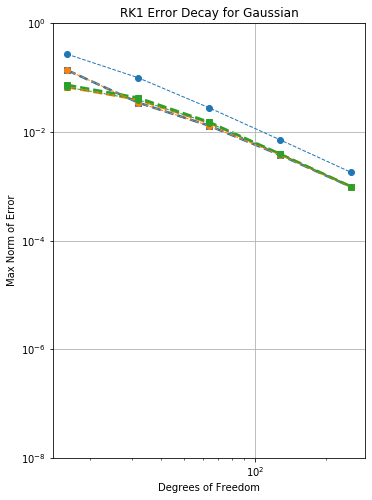

In [11]:
scale = 0.8
figsize = list(scale * np.asarray([7, 10]))

fig, ax = plt.subplots(figsize = figsize)
plt.title(title)
plt.ylabel('Max Norm of Error')
plt.xlabel('Degrees of Freedom')
plt.grid(True)
plt.xscale('log')
plt.yscale('log')
plt.ylim([10**-8, 1])

for b in range(UA):
    if (b == 0):
        
        if (not Uniform):
            # Skip first iteration if not using uniform grid. [v]
            continue
        
        # Then run uniform grid protocol. [v]
        AMR = False
        linestyle = '-'
        gridLab = ' Uniform'
    
        for a in range(AM):
            if (a == 0):
                
                if (not Advect):
                    # Skip first iteration if not advecting. [v]
                    continue
                
                physics, methLab, alpha = GetPhysInfo(omega0, 'Advection', Two)
                
                for o in range(6):
                    print('')
                    print ('B A O:', b, a, o)
                    print('')
                    order, diff, color, marker, zorder, linewidth = GetOrderInfo(o)
                    label = 'Order-' + str(order) + gridLab + methLab
                    # Run convergence test. [v]
                    nhVec, errGrid[b][a][order - 1] = WaveEqConvergenceTest(omega0, physics, CFL, RK, order, diff, func, args, dataPts, AMR, numRefCel = 4, plot = plot, derivative = derivative)
                    line, = ax.plot(nhVec, errGrid[b][a][order - 1], zorder = zorder, linestyle = linestyle, color = color, alpha = alpha, linewidth = linewidth, marker = marker)#, label = label)
                    legends.append(line)
                    labels.append(label)

            else:
                
                physics, methLab, alpha = GetPhysInfo(omega0, 'Maxwell', Two)
                    
                for o in range(6):
                    print('')
                    print ('B A O:', b, a, o)
                    print('')
                    order, diff, color, marker, zorder, linewidth = GetOrderInfo(o)
                    label = 'Order-' + str(order) + gridLab + methLab
                    # Run convergence test. [v]
                    nhVec, errGrid[b][a][order - 1] = WaveEqConvergenceTest(omega0, physics, CFL, RK, order, diff, func, args, dataPts, AMR, numRefCel = 4, plot = plot, derivative = derivative)
                    line, = ax.plot(nhVec, errGrid[b][a][order - 1], zorder = zorder, linestyle = linestyle, color = color, alpha = alpha, linewidth = linewidth, marker = marker)#, label = label)
                    legends.append(line)
                    labels.append(label)
    else:
        # Then run AMR grid protocol. [v]
        AMR = True
        linestyle = '--'
        gridLab = ' Localized Mesh'
        
        for a in range(AM):
            if (a == 0):
                if (not Advect):
                    # Skip first iteration if not advecting. [v]
                    continue
                
                physics, methLab, alpha = GetPhysInfo(omega0, 'Advection', Two)
                
                for o in range(6):
                    print('')
                    print ('B A O:', b, a, o)
                    print('')
                    order, diff, color, marker, zorder, linewidth = GetOrderInfo(o)
                    label = 'Order-' + str(order) + gridLab + methLab
                    # Run convergence test. [v]
                    nhVec, errGrid[b][a][order - 1] = WaveEqConvergenceTest(omega0, physics, CFL, RK, order, diff, func, args, dataPts, AMR, numRefCel = 4, plot = plot, derivative = derivative)
                    line, = ax.plot(nhVec, errGrid[b][a][order - 1], zorder = zorder, linestyle = linestyle, color = color, alpha = alpha, linewidth = linewidth, marker = marker)#, label = label)
                    legends.append(line)
                    labels.append(label)
            else:
                
                physics, methLab, alpha = GetPhysInfo(omega0, 'Maxwell', Two)
                
                for o in range(6):
                    print('')
                    print ('B A O:', b, a, o)
                    print('')
                    order, diff, color, marker, zorder, linewidth = GetOrderInfo(o)
                    label = 'Order-' + str(order) + gridLab + methLab
                    # Run convergence test. [v]
                    nhVec, errGrid[b][a][order - 1] = WaveEqConvergenceTest(omega0, physics, CFL, RK, order, diff, func, args, dataPts, AMR, numRefCel = 4, plot = plot, derivative = derivative)
                    line, = ax.plot(nhVec, errGrid[b][a][order - 1], zorder = zorder, linestyle = linestyle, color = color, alpha = alpha, linewidth = linewidth, marker = marker)#, label = label)
                    legends.append(line)
                    labels.append(label)



saveName = '/Users/sashacurcic/SashasDirectory/ANAG/FV_MG/Figures/ConvergenceRK' + str(RK) # + appendage
fig.savefig(saveName + '.png', bbox_inches = 'tight', dpi = 600, transparent = True)
plt.show()
                    

In [12]:
legFig = plt.figure()
legFig.legend(legends, labels, loc='center')
saveName = '/Users/sashacurcic/SashasDirectory/ANAG/FV_MG/Figures/Legend'
legFig.savefig(saveName + '.png', bbox_inches = 'tight', dpi = 600, transparent = True)
plt.show()
print(legends)
print(labels)

<Figure size 432x288 with 0 Axes>

[<matplotlib.lines.Line2D object at 0x7fe7ed5b22b0>, <matplotlib.lines.Line2D object at 0x7fe7ea8edda0>, <matplotlib.lines.Line2D object at 0x7fe7ed42c5c0>, <matplotlib.lines.Line2D object at 0x7fe7ea9e7f60>, <matplotlib.lines.Line2D object at 0x7fe7ea8ed400>, <matplotlib.lines.Line2D object at 0x7fe7ea9e7a58>]
['Order-1 Localized Mesh Maxwell', 'Order-2 Localized Mesh Maxwell', 'Order-3 Localized Mesh Maxwell', 'Order-4 Localized Mesh Maxwell', 'Order-5 Localized Mesh Maxwell', 'Order-6 Localized Mesh Maxwell']


In [13]:
if (AMR):
    grid = 'AMR'
else:
    grid = 'Uniform'
    
gridFile = grid + '/'

meds = 'SingleMed'
medsFile = '1Medium/'
if (locs == []):
    eqs = 'Advect'
    eqsFile = eqs + 'ion/'
else:
    eqs = 'Max'
    eqsFile = eqs + 'well/'
    if ((epsilons[0] != epsilons[1]) or (mus[0] != mus[1])):
        meds = 'DualMed'
        medsFile = '2Media/'


# if ((locs == []) or ((epsilons[0] == epsilons[1]) and (mus[0] == mus[1]))):
#     meds = 'SingleMed'
#     eqs = 'Advect'
# else:
#     meds = 'DualMed'

savePathInit = '/Users/sashacurcic/SashasDirectory/ANAG/FV_MG/Figures/'


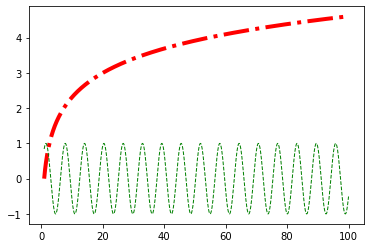

<Figure size 432x288 with 0 Axes>

In [14]:
x = np.linspace(1, 100, 1000)
y = np.log(x)
y1 = np.sin(x)
fig = plt.figure("Line plot")
legendFig = plt.figure("Legend plot")
ax = fig.add_subplot(111)
line1, = ax.plot(x, y, c="red", lw=4, linestyle="dashdot")
line2, = ax.plot(x, y1, c="green", lw=1, linestyle="--")
legendFig.legend([line1, line2], ["y=log(x)", "y=sin(x)"], loc='center')
legendFig.savefig('legend.png')